In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Carichiamo le osservazioni CBS
obs = pd.read_csv(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\Observations.csv", sep=';')
print(f"Righe: {len(obs)}")
print(obs.columns.tolist())
obs.head()

Righe: 2071697
['Id', 'Measure', 'WijkenEnBuurten', 'Value', 'StringValue', 'ValueAttribute']


,Id,Measure,WijkenEnBuurten,Value,StringValue,ValueAttribute
0,0,GM000C,NL00,NaN,Nederland,NaN
1,1,R00003,NL00,NaN,Land,NaN
2,2,R00004,NL00,NaN,NL00,NaN
3,3,T001036,NL00,17811291,NaN,NaN
4,4,3000,NL00,8850309,NaN,NaN


In [2]:
# Carichiamo i codici dei quartieri
codes = pd.read_csv(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\WijkenEnBuurtenCodes.csv", sep=';')
print(f"Righe: {len(codes)}")
print(codes.columns.tolist())

# Cerchiamo Amsterdam
amsterdam = codes[codes['Title'].str.contains('Amsterdam', case=False, na=False)]
print(f"\nZone con 'Amsterdam': {len(amsterdam)}")
print(amsterdam.head(20))

Righe: 18116
['Identifier', 'DimensionGroupId', 'DimensionId', 'Index', 'Title', 'Description', 'DetailRegionCode']

Zone con 'Amsterdam': 14
       Identifier DimensionGroupId      DimensionId  Index  \
1167     WK036214           GM0362  WijkenEnBuurten   1168   
1168   BU03621401           GM0362  WijkenEnBuurten   1169   
1169   BU03621402           GM0362  WijkenEnBuurten   1170   
1170       GM0363               GM  WijkenEnBuurten   1171   
1525   BU0363KQ01           GM0363  WijkenEnBuurten   1526   
1751     WK0363TC           GM0363  WijkenEnBuurten   1752   
1754   BU0363TC03           GM0363  WijkenEnBuurten   1755   
5312     WK011406           GM0114  WijkenEnBuurten   5313   
5313   BU01140600           GM0114  WijkenEnBuurten   5314   
5316   BU01140609           GM0114  WijkenEnBuurten   5317   
5319   BU01140701           GM0114  WijkenEnBuurten   5320   
6634     WK039207           GM0392  WijkenEnBuurten   6635   
6635   BU03920701           GM0392  WijkenEnBuurten 

In [3]:
# Tutti i buurt di Amsterdam
amsterdam_buurten = codes[codes['Identifier'].str.startswith('BU0363', na=False)]
print(f"Buurt di Amsterdam: {len(amsterdam_buurten)}")

# Troviamo il codice per la popolazione totale
# T001036 sembra essere la popolazione — verifichiamo
pop_data = obs[
    (obs['WijkenEnBuurten'].isin(amsterdam_buurten['Identifier'])) &
    (obs['Measure'] == 'T001036') &
    (obs['Value'].notna())
].copy()

print(f"\nRecord popolazione Amsterdam: {len(pop_data)}")
print(pop_data.head(10))

Buurt di Amsterdam: 517

Record popolazione Amsterdam: 517
            Id  Measure WijkenEnBuurten Value StringValue ValueAttribute
132460  132460  T001036      BU0363AA01   345         NaN            NaN
132577  132577  T001036      BU0363AA02  2910         NaN            NaN
132702  132702  T001036      BU0363AA03  1825         NaN            NaN
132820  132820  T001036      BU0363AA04   165         NaN            NaN
132930  132930  T001036      BU0363AA05  2375         NaN            NaN
133049  133049  T001036      BU0363AA06  1515         NaN            NaN
133287  133287  T001036      BU0363AB01  1455         NaN            NaN
133404  133404  T001036      BU0363AB02  2725         NaN            NaN
133525  133525  T001036      BU0363AB03  2095         NaN            NaN
133646  133646  T001036      BU0363AB04   915         NaN            NaN


In [4]:
# Uniamo popolazione con i nomi dei buurt
pop_named = pop_data.merge(
    amsterdam_buurten[['Identifier', 'Title']],
    left_on='WijkenEnBuurten',
    right_on='Identifier',
    how='left'
)

pop_named = pop_named[['WijkenEnBuurten', 'Title', 'Value']].copy()
pop_named.columns = ['CBS_code', 'Buurt_CBS', 'Popolazione']

print(f"Buurt con popolazione: {len(pop_named)}")
print(f"Popolazione totale Amsterdam: {pop_named['Popolazione'].sum():,}")
print(pop_named.sort_values('Popolazione', ascending=False).head(10))

Buurt con popolazione: 517


ValueError: Cannot specify ',' with 's'.

In [5]:
pop_named['Popolazione'] = pd.to_numeric(pop_named['Popolazione'], errors='coerce')

print(f"Buurt con popolazione: {len(pop_named)}")
print(f"Popolazione totale Amsterdam: {pop_named['Popolazione'].sum():,.0f}")
print(pop_named.sort_values('Popolazione', ascending=False).head(10))

Buurt con popolazione: 517
Popolazione totale Amsterdam: 917,890
       CBS_code                  Buurt_CBS  Popolazione
187  BU0363FH02        Dijkgraafpleinbuurt         6210
191  BU0363FJ04      Zuidwestkwadrant-Zuid         6175
163  BU0363FB03  Ruys de Beerenbrouckbuurt         6105
349  BU0363ML02     Theo van Goghparkbuurt         6055
201  BU0363FM02      Overtoomse Veld-Noord         6030
342  BU0363MJ05        Ed Pelsterparkbuurt         5900
185  BU0363FG03               De Aker-Oost         5865
146  BU0363ET01           Cremerbuurt-West         5690
328  BU0363MG01         Makassarpleinbuurt         5610
102  BU0363EE01                   Bosleeuw         5485


In [6]:
import geopandas as gpd

buurten = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\geojson_lnglat_2.json")
print(buurten.columns.tolist())
print(buurten.head(3))

['CBS_Buurtcode', 'Buurtcode', 'Buurt', 'Wijkcode', 'Wijk', 'Gebiedcode', 'Gebied', 'Stadsdeelcode', 'Stadsdeel', 'Oppervlakte_m2', 'geometry']
  CBS_Buurtcode Buurtcode                Buurt Wijkcode             Wijk  \
0    BU0363AA01      AA01  Planciusbuurt-Noord       AA  Haarlemmerbuurt   
1    BU0363AA02      AA02  Westelijke eilanden       AA  Haarlemmerbuurt   
2    BU0363AA03      AA03     Westerdokseiland       AA  Haarlemmerbuurt   

  Gebiedcode        Gebied Stadsdeelcode Stadsdeel  Oppervlakte_m2  \
0       GA01  Centrum-West             A   Centrum           24034   
1       GA01  Centrum-West             A   Centrum          215741   
2       GA01  Centrum-West             A   Centrum          336484   

                                            geometry  
0  POLYGON ((4.88304 52.386, 4.88408 52.38567, 4....  
1  POLYGON ((4.88393 52.38551, 4.88465 52.3852, 4...  
2  POLYGON ((4.89018 52.3824, 4.89064 52.38218, 4...  


In [7]:
# Uniamo i dati geografici con la popolazione
buurten_pop = buurten.merge(
    pop_named[['CBS_code', 'Popolazione']],
    left_on='CBS_Buurtcode',
    right_on='CBS_code',
    how='left'
)

print(f"Buurt con popolazione: {buurten_pop['Popolazione'].notna().sum()}")
print(f"Popolazione totale: {buurten_pop['Popolazione'].sum():,.0f}")
print(f"\nTop 5 buurt più popolosi:")
print(buurten_pop[['Buurt', 'Stadsdeel', 'Popolazione']].sort_values('Popolazione', ascending=False).head())

Buurt con popolazione: 517
Popolazione totale: 917,890

Top 5 buurt più popolosi:
                         Buurt   Stadsdeel  Popolazione
187        Dijkgraafpleinbuurt  Nieuw-West       6210.0
191      Zuidwestkwadrant-Zuid  Nieuw-West       6175.0
163  Ruys de Beerenbrouckbuurt  Nieuw-West       6105.0
350     Theo van Goghparkbuurt        Oost       6055.0
201      Overtoomse Veld-Noord  Nieuw-West       6030.0


In [8]:
# Proiettiamo in EPSG:28992 per lavorare in metri
buurten_proj = buurten_pop.to_crs("EPSG:28992")
green = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\park_geojson_lnglat.json",
                      on_invalid="ignore")
green_proj = green.to_crs("EPSG:28992")

# Buffer 500m attorno ai parchi
buffer_union = green_proj.geometry.buffer(500).union_all()

# Per ogni buurt calcoliamo la percentuale di area coperta dal buffer
buurten_proj['area_totale'] = buurten_proj.geometry.area
buurten_proj['area_coperta'] = buurten_proj.geometry.intersection(buffer_union).area
buurten_proj['perc_area'] = (buurten_proj['area_coperta'] / buurten_proj['area_totale']).clip(0, 1)

# Popolazione accessibile = popolazione * percentuale di area coperta
buurten_proj['pop_accessibile'] = buurten_proj['Popolazione'] * buurten_proj['perc_area']

# Risultato finale
pop_totale = buurten_proj['Popolazione'].sum()
pop_accessibile = buurten_proj['pop_accessibile'].sum()
perc_pop = pop_accessibile / pop_totale * 100

print(f"Popolazione totale: {pop_totale:,.0f}")
print(f"Popolazione entro 500m da un parco: {pop_accessibile:,.0f}")
print(f"Percentuale: {perc_pop:.1f}%")

Popolazione totale: 917,890
Popolazione entro 500m da un parco: 712,175
Percentuale: 77.6%


In [9]:
access_stadsdeel = buurten_proj.groupby('Stadsdeel').agg(
    Pop_totale=('Popolazione', 'sum'),
    Pop_accessibile=('pop_accessibile', 'sum')
).reset_index()

access_stadsdeel['Perc_pop_accessibile'] = (
    access_stadsdeel['Pop_accessibile'] / access_stadsdeel['Pop_totale'] * 100
).round(1)

print(access_stadsdeel[['Stadsdeel', 'Pop_totale', 'Perc_pop_accessibile']]
      .sort_values('Perc_pop_accessibile', ascending=False))

    Stadsdeel  Pop_totale  Perc_pop_accessibile
5        West    148555.0                  87.4
7        Zuid    148035.0                  84.0
3        Oost    145835.0                  79.5
8    Zuidoost     90385.0                  78.8
1  Nieuw-West    163425.0                  77.6
2       Noord    106885.0                  74.3
0     Centrum     89980.0                  68.9
4       Weesp     23770.0                  11.0
6   Westpoort      1020.0                   6.7


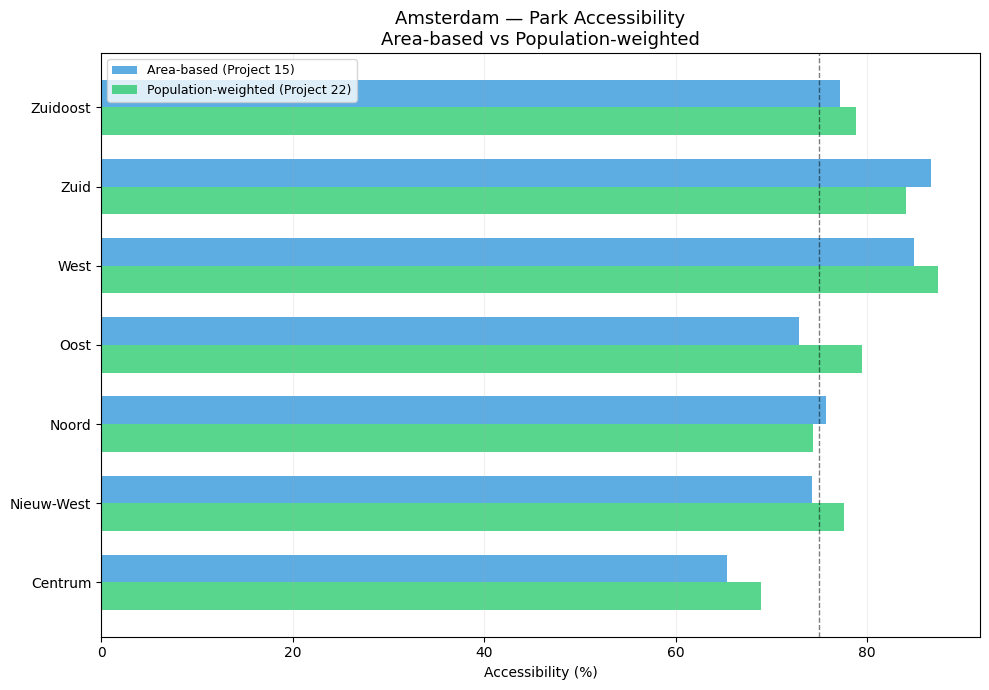

In [10]:
import matplotlib.pyplot as plt

# Confronto tra i due approcci
stadsdeel_confronto = access_stadsdeel[
    ~access_stadsdeel['Stadsdeel'].isin(['Weesp', 'Westpoort'])
].copy()

# Dati superficie dal progetto 15
superficie = {
    'Zuid': 86.7, 'West': 84.9, 'Zuidoost': 77.2, 
    'Noord': 75.7, 'Nieuw-West': 74.2, 'Oost': 72.9, 'Centrum': 65.4
}
stadsdeel_confronto['Perc_superficie'] = stadsdeel_confronto['Stadsdeel'].map(superficie)

fig, ax = plt.subplots(figsize=(10, 7))

x = range(len(stadsdeel_confronto))
width = 0.35

bars1 = ax.barh([i + width/2 for i in x], 
                stadsdeel_confronto['Perc_superficie'],
                width, label='Area-based (Project 15)', color='#3498db', alpha=0.8)
bars2 = ax.barh([i - width/2 for i in x],
                stadsdeel_confronto['Perc_pop_accessibile'],
                width, label='Population-weighted (Project 22)', color='#2ecc71', alpha=0.8)

ax.set_yticks(list(x))
ax.set_yticklabels(stadsdeel_confronto['Stadsdeel'])
ax.set_xlabel('Accessibility (%)')
ax.set_title('Amsterdam — Park Accessibility\nArea-based vs Population-weighted', fontsize=13)
ax.legend(fontsize=9)
ax.axvline(x=75, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.grid(True, alpha=0.2, axis='x')

plt.tight_layout()
plt.savefig('amsterdam_accessibility_comparison.png', dpi=150, bbox_inches='tight')
plt.show()